<a href="https://colab.research.google.com/github/nharri64/ECGR-4105/blob/HW2/Noah_Harris_801353171_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 2 - Linear Regression with Gradient Descent

Noah Harris
Student ID: 801353171

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from google.colab import files

In [88]:
uploaded = files.upload()

data = pd.read_csv('Housing.csv')

print(data.head())
print("\nShape:", data.shape)
print("\nColumns:")
print(data.columns)

Saving Housing.csv to Housing (3).csv
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Shape: (545, 13)

Columns:
Index(['price', 'area', 'bedrooms

In [89]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in binary_columns:
    data[column] = data[column].map({'yes': 1, 'no': 0})

print(data.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  


In [90]:
train_data, test_data = train_test_split(
    data,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))

Training samples: 436
Test samples: 109


Problem 1a - Linear Regression with Five Input Variables

In [91]:
features_1a = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

X_train_1a = train_data[features_1a].values.astype(float)
X_test_1a = test_data[features_1a].values.astype(float)

y_train = train_data['price'].values.astype(float)
y_test = test_data['price'].values.astype(float)

In [92]:
scale_1a = np.max(np.abs(X_train_1a), axis=0)

X_train_1a_scaled = X_train_1a / scale_1a
X_test_1a_scaled = X_test_1a / scale_1a

In [93]:
def gradient_descent(X_train, y_train, X_test, y_test,
                     learning_rate, iterations):

    m_train = len(y_train)
    m_test = len(y_test)

    # Add bias column
    X_train_bias = np.c_[np.ones(m_train), X_train]
    X_test_bias = np.c_[np.ones(m_test), X_test]

    # Initialize all theta values to zero
    theta = np.zeros(X_train_bias.shape[1])

    train_losses = []
    validation_losses = []

    for i in range(iterations):

        # Training predictions
        train_predictions = X_train_bias @ theta
        train_error = train_predictions - y_train

        # Training loss
        train_loss = (1 / (2 * m_train)) * np.sum(train_error ** 2)
        train_losses.append(train_loss)

        # Gradient
        gradient = (1 / m_train) * (X_train_bias.T @ train_error)

        # Update theta
        theta = theta - learning_rate * gradient

        # Validation predictions
        validation_predictions = X_test_bias @ theta
        validation_error = validation_predictions - y_test

        # Validation loss
        validation_loss = (1 / (2 * m_test)) * np.sum(
            validation_error ** 2
        )
        validation_losses.append(validation_loss)

    return theta, train_losses, validation_losses

In [94]:
learning_rates = [0.01, 0.05, 0.1]
iterations = 5000

results_1a = {}

for lr in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_train_1a_scaled,
        y_train,
        X_test_1a_scaled,
        y_test,
        learning_rate=lr,
        iterations=iterations
    )

    results_1a[lr] = (
        theta_temp,
        train_temp,
        val_temp
    )

    print("Learning Rate:", lr)
    print("Training Loss:", train_temp[-1])
    print("Validation Loss:", val_temp[-1])
    print()

Learning Rate: 0.01
Training Loss: 736813836448.2416
Validation Loss: 1260903253254.8806

Learning Rate: 0.05
Training Loss: 675433613405.0591
Validation Loss: 1146182823093.491

Learning Rate: 0.1
Training Loss: 675007648606.1143
Validation Loss: 1146084532745.1465



In [95]:
best_lr_1a = min(
    results_1a,
    key=lambda lr: results_1a[lr][2][-1]
)

theta_1a, train_1a, val_1a = results_1a[best_lr_1a]

print("Problem 1a Final Results")
print("Best Learning Rate:", best_lr_1a)
print("Iterations:", iterations)
print("Best Parameters:", theta_1a)
print("Final Training Loss:", train_1a[-1])
print("Final Validation Loss:", val_1a[-1])

Problem 1a Final Results
Best Learning Rate: 0.1
Iterations: 5000
Best Parameters: [  49746.03742284 5003889.50057439  925702.71355963 4721530.66286176
 1979911.16941257 1013730.33881771]
Final Training Loss: 675007648606.1143
Final Validation Loss: 1146084532745.1465


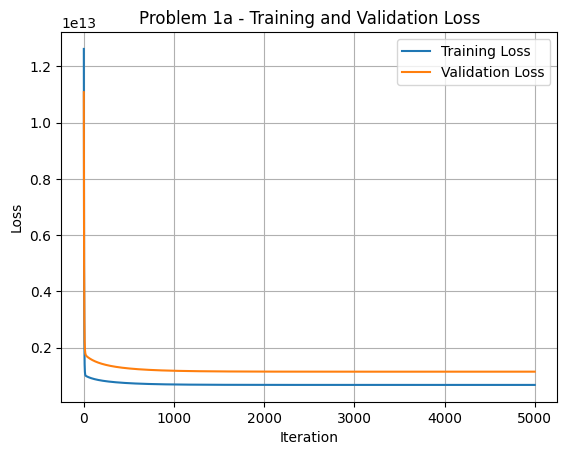

In [96]:
plt.plot(train_1a, label='Training Loss')
plt.plot(val_1a, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Problem 1a - Training and Validation Loss')
plt.legend()
plt.grid()

plt.show()

Problem 1b - Linear Regression with Eleven Input Variables

In [97]:
features_1b = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

X_train_1b = train_data[features_1b].values.astype(float)
X_test_1b = test_data[features_1b].values.astype(float)

In [98]:
scale_1b = np.max(np.abs(X_train_1b), axis=0)

X_train_1b_scaled = X_train_1b / scale_1b
X_test_1b_scaled = X_test_1b / scale_1b

In [99]:
results_1b = {}

for lr in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_train_1b_scaled,
        y_train,
        X_test_1b_scaled,
        y_test,
        learning_rate=lr,
        iterations=iterations
    )

    results_1b[lr] = (
        theta_temp,
        train_temp,
        val_temp
    )

    print("Learning Rate:", lr)
    print("Training Loss:", train_temp[-1])
    print("Validation Loss:", val_temp[-1])
    print()

Learning Rate: 0.01
Training Loss: 544754012558.4291
Validation Loss: 938517654020.9926

Learning Rate: 0.05
Training Loss: 496712536813.6491
Validation Loss: 895037857176.1997

Learning Rate: 0.1
Training Loss: 496244888443.662
Validation Loss: 899686477508.5521



In [100]:
best_lr_1b = min(
    results_1b,
    key=lambda lr: results_1b[lr][2][-1]
)

theta_1b, train_1b, val_1b = results_1b[best_lr_1b]

print("Problem 1b Final Results")
print("Best Learning Rate:", best_lr_1b)
print("Iterations:", iterations)
print("Best Parameters:", theta_1b)
print("Final Training Loss:", train_1b[-1])
print("Final Validation Loss:", val_1b[-1])

Problem 1b Final Results
Best Learning Rate: 0.05
Iterations: 5000
Best Parameters: [ -57101.07160485 3766818.84082622  631155.81457288 4187668.09871147
 1705278.52787251  418626.12516539  250898.61066117  432915.79713452
  717208.38195405  815162.91958378  765353.63568659  635313.01666009]
Final Training Loss: 496712536813.6491
Final Validation Loss: 895037857176.1997


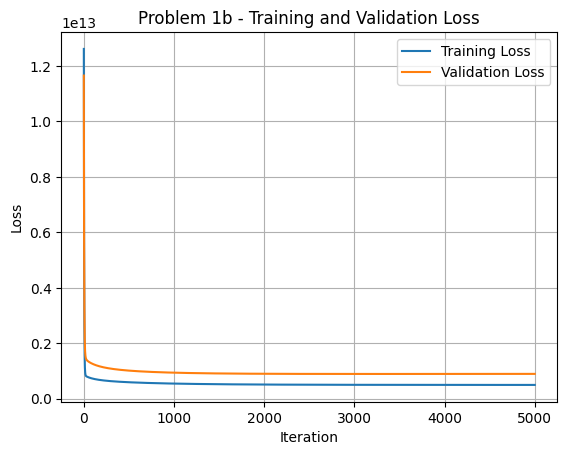

In [101]:
plt.plot(train_1b, label='Training Loss')
plt.plot(val_1b, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Problem 1b - Training and Validation Loss')
plt.legend()
plt.grid()

plt.show()

In [102]:
print("Problem 1a vs Problem 1b Comparison")

print("\nProblem 1a")
print("Number of Features: 5")
print("Best Learning Rate:", best_lr_1a)
print("Training Loss:", train_1a[-1])
print("Validation Loss:", val_1a[-1])

print("\nProblem 1b")
print("Number of Features: 11")
print("Best Learning Rate:", best_lr_1b)
print("Training Loss:", train_1b[-1])
print("Validation Loss:", val_1b[-1])

print("\nComparison")

if val_1b[-1] < val_1a[-1]:
    print("Problem 1b has the lower validation loss.")
    print("The additional input variables improved the model's performance.")
elif val_1b[-1] > val_1a[-1]:
    print("Problem 1a has the lower validation loss.")
    print("The additional input variables in Problem 1b did not improve validation performance.")
else:
    print("Problem 1a and Problem 1b have the same validation loss.")

Problem 1a vs Problem 1b Comparison

Problem 1a
Number of Features: 5
Best Learning Rate: 0.1
Training Loss: 675007648606.1143
Validation Loss: 1146084532745.1465

Problem 1b
Number of Features: 11
Best Learning Rate: 0.05
Training Loss: 496712536813.6491
Validation Loss: 895037857176.1997

Comparison
Problem 1b has the lower validation loss.
The additional input variables improved the model's performance.


Problem 2A

In [103]:
normalizer_2a = MinMaxScaler()

X_train_2a_norm = normalizer_2a.fit_transform(X_train_1a)
X_test_2a_norm = normalizer_2a.transform(X_test_1a)

In [104]:
results_2a_norm = {}

for lr in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_train_2a_norm,
        y_train,
        X_test_2a_norm,
        y_test,
        learning_rate=lr,
        iterations=5000
    )

    results_2a_norm[lr] = (
        theta_temp,
        train_temp,
        val_temp
    )

    print("Learning Rate:", lr)
    print("Training Loss:", train_temp[-1])
    print("Validation Loss:", val_temp[-1])
    print()

Learning Rate: 0.01
Training Loss: 704070816725.4316
Validation Loss: 1196961694616.0938

Learning Rate: 0.05
Training Loss: 675037689313.3507
Validation Loss: 1146427176271.3594

Learning Rate: 0.1
Training Loss: 675004141072.9407
Validation Loss: 1146340457070.4438



In [105]:
standardizer_2a = StandardScaler()

X_train_2a_std = standardizer_2a.fit_transform(X_train_1a)
X_test_2a_std = standardizer_2a.transform(X_test_1a)

In [106]:
results_2a_std = {}

for lr in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_train_2a_std,
        y_train,
        X_test_2a_std,
        y_test,
        learning_rate=lr,
        iterations=5000
    )

    results_2a_std[lr] = (
        theta_temp,
        train_temp,
        val_temp
    )

    print("Learning Rate:", lr)
    print("Training Loss:", train_temp[-1])
    print("Validation Loss:", val_temp[-1])
    print()

Learning Rate: 0.01
Training Loss: 675004105663.2902
Validation Loss: 1146360772862.6917

Learning Rate: 0.05
Training Loss: 675004105663.2902
Validation Loss: 1146360772862.6843

Learning Rate: 0.1
Training Loss: 675004105663.2902
Validation Loss: 1146360772862.6836



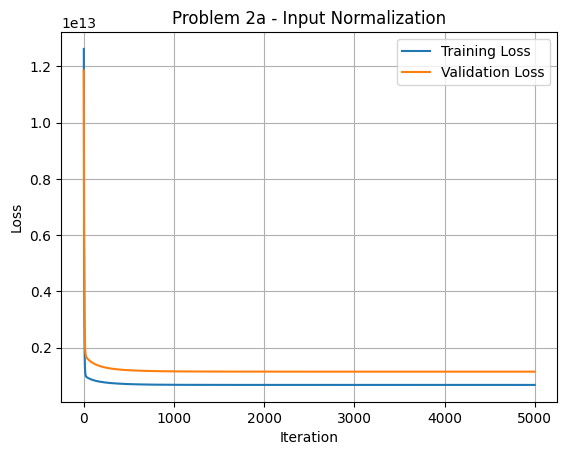

In [107]:
best_lr_2a_norm = min(
    results_2a_norm,
    key=lambda lr: results_2a_norm[lr][2][-1]
)

theta_2a_norm, train_2a_norm, val_2a_norm = results_2a_norm[best_lr_2a_norm]

plt.plot(train_2a_norm, label='Training Loss')
plt.plot(val_2a_norm, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Problem 2a - Input Normalization')
plt.legend()
plt.grid()

plt.show()

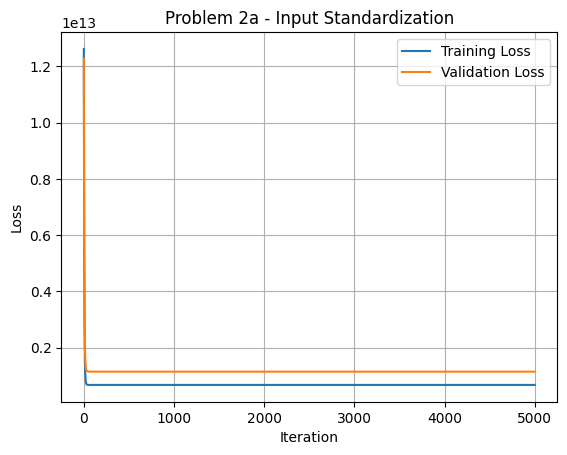

In [108]:
best_lr_2a_std = min(
    results_2a_std,
    key=lambda lr: results_2a_std[lr][2][-1]
)

theta_2a_std, train_2a_std, val_2a_std = results_2a_std[best_lr_2a_std]

plt.plot(train_2a_std, label='Training Loss')
plt.plot(val_2a_std, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Problem 2a - Input Standardization')
plt.legend()
plt.grid()

plt.show()

In [109]:
print("Problem 2a Training Comparison")

print("\nBaseline Problem 1a")
print("Training Loss:", train_1a[-1])
print("Validation Loss:", val_1a[-1])

print("\nNormalization")
print("Best Learning Rate:", best_lr_2a_norm)
print("Training Loss:", train_2a_norm[-1])
print("Validation Loss:", val_2a_norm[-1])

print("\nStandardization")
print("Best Learning Rate:", best_lr_2a_std)
print("Training Loss:", train_2a_std[-1])
print("Validation Loss:", val_2a_std[-1])

training_losses_2a = {
    "Baseline 1a": train_1a[-1],
    "Normalization": train_2a_norm[-1],
    "Standardization": train_2a_std[-1]
}

best_training_2a = min(training_losses_2a, key=training_losses_2a.get)

print("\nBest Training Result:", best_training_2a)
print("Lowest Training Loss:", training_losses_2a[best_training_2a])

Problem 2a Training Comparison

Baseline Problem 1a
Training Loss: 675007648606.1143
Validation Loss: 1146084532745.1465

Normalization
Best Learning Rate: 0.1
Training Loss: 675004141072.9407
Validation Loss: 1146340457070.4438

Standardization
Best Learning Rate: 0.1
Training Loss: 675004105663.2902
Validation Loss: 1146360772862.6836

Best Training Result: Standardization
Lowest Training Loss: 675004105663.2902


Problem 2B

In [110]:
normalizer_2b = MinMaxScaler()

X_train_2b_norm = normalizer_2b.fit_transform(X_train_1b)
X_test_2b_norm = normalizer_2b.transform(X_test_1b)

results_2b_norm = {}

for lr in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_train_2b_norm,
        y_train,
        X_test_2b_norm,
        y_test,
        learning_rate=lr,
        iterations=5000
    )

    results_2b_norm[lr] = (
        theta_temp,
        train_temp,
        val_temp
    )

    print("Learning Rate:", lr)
    print("Training Loss:", train_temp[-1])
    print("Validation Loss:", val_temp[-1])
    print()

Learning Rate: 0.01
Training Loss: 519848363759.34045
Validation Loss: 900940246797.0948

Learning Rate: 0.05
Training Loss: 496293120412.3996
Validation Loss: 898741482750.3403

Learning Rate: 0.1
Training Loss: 496240576469.3895
Validation Loss: 900319832474.287



In [111]:
standardizer_2b = StandardScaler()

X_train_2b_std = standardizer_2b.fit_transform(X_train_1b)
X_test_2b_std = standardizer_2b.transform(X_test_1b)

results_2b_std = {}

for lr in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_train_2b_std,
        y_train,
        X_test_2b_std,
        y_test,
        learning_rate=lr,
        iterations=5000
    )

    results_2b_std[lr] = (
        theta_temp,
        train_temp,
        val_temp
    )

    print("Learning Rate:", lr)
    print("Training Loss:", train_temp[-1])
    print("Validation Loss:", val_temp[-1])
    print()

Learning Rate: 0.01
Training Loss: 496240500004.89264
Validation Loss: 900396859834.4525

Learning Rate: 0.05
Training Loss: 496240500004.89264
Validation Loss: 900396859859.4875

Learning Rate: 0.1
Training Loss: 496240500004.89264
Validation Loss: 900396859859.4867



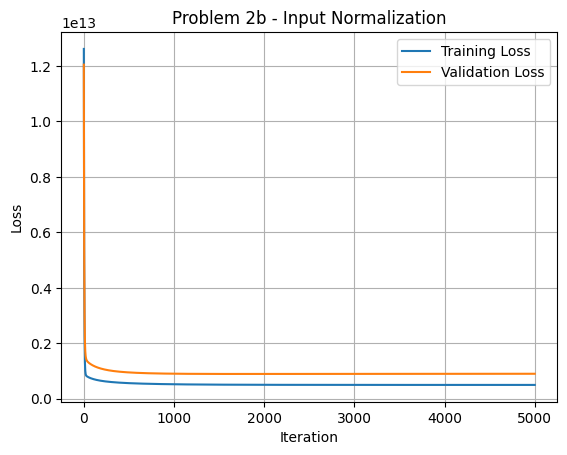

In [112]:
best_lr_2b_norm = min(
    results_2b_norm,
    key=lambda lr: results_2b_norm[lr][2][-1]
)

theta_2b_norm, train_2b_norm, val_2b_norm = results_2b_norm[best_lr_2b_norm]

plt.plot(train_2b_norm, label='Training Loss')
plt.plot(val_2b_norm, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Problem 2b - Input Normalization')
plt.legend()
plt.grid()

plt.show()

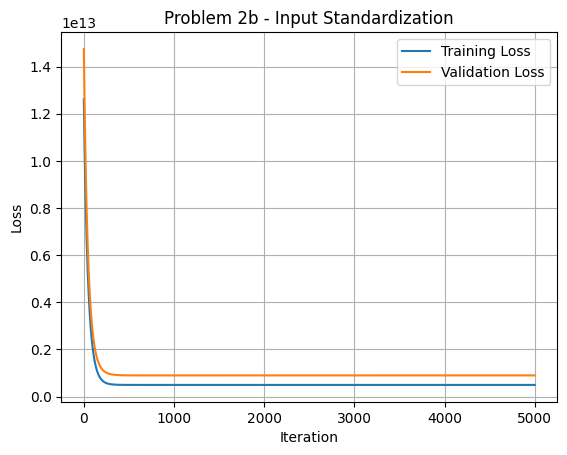

In [113]:
best_lr_2b_std = min(
    results_2b_std,
    key=lambda lr: results_2b_std[lr][2][-1]
)

theta_2b_std, train_2b_std, val_2b_std = results_2b_std[best_lr_2b_std]

plt.plot(train_2b_std, label='Training Loss')
plt.plot(val_2b_std, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Problem 2b - Input Standardization')
plt.legend()
plt.grid()

plt.show()

In [114]:
print("Problem 2b Training Comparison")

print("\nBaseline Problem 1b")
print("Training Loss:", train_1b[-1])
print("Validation Loss:", val_1b[-1])

print("\nNormalization")
print("Best Learning Rate:", best_lr_2b_norm)
print("Training Loss:", train_2b_norm[-1])
print("Validation Loss:", val_2b_norm[-1])

print("\nStandardization")
print("Best Learning Rate:", best_lr_2b_std)
print("Training Loss:", train_2b_std[-1])
print("Validation Loss:", val_2b_std[-1])

training_losses_2b = {
    "Baseline 1b": train_1b[-1],
    "Normalization": train_2b_norm[-1],
    "Standardization": train_2b_std[-1]
}

best_training_2b = min(training_losses_2b, key=training_losses_2b.get)

print("\nBest Training Result:", best_training_2b)
print("Lowest Training Loss:", training_losses_2b[best_training_2b])

Problem 2b Training Comparison

Baseline Problem 1b
Training Loss: 496712536813.6491
Validation Loss: 895037857176.1997

Normalization
Best Learning Rate: 0.05
Training Loss: 496293120412.3996
Validation Loss: 898741482750.3403

Standardization
Best Learning Rate: 0.01
Training Loss: 496240500004.89264
Validation Loss: 900396859834.4525

Best Training Result: Standardization
Lowest Training Loss: 496240500004.89264


Problem 3 - Linear Regression with Parameter Penalty


In [115]:
def gradient_descent_regularized(
    X_train, y_train, X_test, y_test,
    learning_rate, iterations, lambda_value
):

    m_train = len(y_train)
    m_test = len(y_test)

    # Add bias column
    X_train_bias = np.c_[np.ones(m_train), X_train]
    X_test_bias = np.c_[np.ones(m_test), X_test]

    # Initialize theta to zero
    theta = np.zeros(X_train_bias.shape[1])

    train_losses = []
    validation_losses = []

    for i in range(iterations):

        # Training predictions
        train_predictions = X_train_bias @ theta
        train_error = train_predictions - y_train

        # Normal training loss
        mse_loss = (1 / (2 * m_train)) * np.sum(train_error ** 2)

        # L2 parameter penalty
        # theta[0] is excluded because the bias is not penalized
        penalty = (lambda_value / (2 * m_train)) * np.sum(theta[1:] ** 2)

        # Training loss includes penalty
        train_loss = mse_loss + penalty
        train_losses.append(train_loss)

        # Normal gradient
        gradient = (1 / m_train) * (X_train_bias.T @ train_error)

        # Add penalty to gradient except theta 0
        gradient[1:] += (lambda_value / m_train) * theta[1:]

        # Update theta
        theta = theta - learning_rate * gradient

        # Evaluation predictions
        validation_predictions = X_test_bias @ theta
        validation_error = validation_predictions - y_test

        # Evaluation loss DOES NOT include penalty
        validation_loss = (1 / (2 * m_test)) * np.sum(
            validation_error ** 2
        )

        validation_losses.append(validation_loss)

    return theta, train_losses, validation_losses

In [116]:
print("Problem 2a Results")

print("\nNormalization")
print("Training Loss:", train_2a_norm[-1])
print("Validation Loss:", val_2a_norm[-1])

print("\nStandardization")
print("Training Loss:", train_2a_std[-1])
print("Validation Loss:", val_2a_std[-1])

Problem 2a Results

Normalization
Training Loss: 675004141072.9407
Validation Loss: 1146340457070.4438

Standardization
Training Loss: 675004105663.2902
Validation Loss: 1146360772862.6836


In [117]:
if val_2a_norm[-1] < val_2a_std[-1]:
    X_train_3a = X_train_2a_norm
    X_test_3a = X_test_2a_norm
    best_scaling_3a = "Normalization"
else:
    X_train_3a = X_train_2a_std
    X_test_3a = X_test_2a_std
    best_scaling_3a = "Standardization"

print("Best scaling for Problem 3a:", best_scaling_3a)

Best scaling for Problem 3a: Normalization


In [118]:
def gradient_descent_regularized(
    X_train, y_train, X_test, y_test,
    learning_rate, iterations, lambda_value
):

    m_train = len(y_train)
    m_test = len(y_test)

    # Add bias column
    X_train_bias = np.c_[np.ones(m_train), X_train]
    X_test_bias = np.c_[np.ones(m_test), X_test]

    # Initialize theta to zero
    theta = np.zeros(X_train_bias.shape[1])

    train_losses = []
    validation_losses = []

    for i in range(iterations):

        # Training predictions
        train_predictions = X_train_bias @ theta
        train_error = train_predictions - y_train

        # Normal training loss
        mse_loss = (1 / (2 * m_train)) * np.sum(train_error ** 2)

        # L2 parameter penalty
        # Do not penalize theta 0
        penalty = (lambda_value / (2 * m_train)) * np.sum(theta[1:] ** 2)

        # Training loss includes the penalty
        train_loss = mse_loss + penalty
        train_losses.append(train_loss)

        # Calculate normal gradient
        gradient = (1 / m_train) * (X_train_bias.T @ train_error)

        # Add L2 penalty to gradient
        # theta 0 is not penalized
        gradient[1:] += (lambda_value / m_train) * theta[1:]

        # Update theta
        theta = theta - learning_rate * gradient

        # Evaluation predictions
        validation_predictions = X_test_bias @ theta
        validation_error = validation_predictions - y_test

        # Evaluation loss does NOT include penalty
        validation_loss = (1 / (2 * m_test)) * np.sum(
            validation_error ** 2
        )

        validation_losses.append(validation_loss)

    return theta, train_losses, validation_losses

In [119]:
lambda_values = [0.01, 0.1, 1.0, 10.0]

learning_rate_3a = 0.1
iterations_3a = 5000

results_3a = {}

for lam in lambda_values:

    theta_temp, train_temp, val_temp = gradient_descent_regularized(
        X_train_3a,
        y_train,
        X_test_3a,
        y_test,
        learning_rate=learning_rate_3a,
        iterations=iterations_3a,
        lambda_value=lam
    )

    results_3a[lam] = (
        theta_temp,
        train_temp,
        val_temp
    )

    print("Lambda:", lam)
    print("Final Training Loss:", train_temp[-1])
    print("Final Validation Loss:", val_temp[-1])
    print()

Lambda: 0.01
Final Training Loss: 675424146416.2015
Final Validation Loss: 1146487924409.75

Lambda: 0.1
Final Training Loss: 679174154414.8761
Final Validation Loss: 1147839083755.911

Lambda: 1.0
Final Training Loss: 713979892029.8596
Final Validation Loss: 1163231653860.316

Lambda: 10.0
Final Training Loss: 924395944492.9597
Final Validation Loss: 1345189435697.0454



In [120]:
best_lambda_3a = min(
    results_3a,
    key=lambda lam: results_3a[lam][2][-1]
)

theta_3a, train_3a, val_3a = results_3a[best_lambda_3a]

print("Problem 3a Final Results")
print("Scaling:", best_scaling_3a)
print("Best Lambda:", best_lambda_3a)
print("Learning Rate:", learning_rate_3a)
print("Iterations:", iterations_3a)
print("Theta:", theta_3a)
print("Final Training Loss:", train_3a[-1])
print("Final Validation Loss:", val_3a[-1])

Problem 3a Final Results
Scaling: Normalization
Best Lambda: 0.01
Learning Rate: 0.1
Iterations: 5000
Theta: [2393925.35378994 4489408.30364364  759069.10069994 3553072.35608822
 1485127.35680423 1013797.72403676]
Final Training Loss: 675424146416.2015
Final Validation Loss: 1146487924409.75


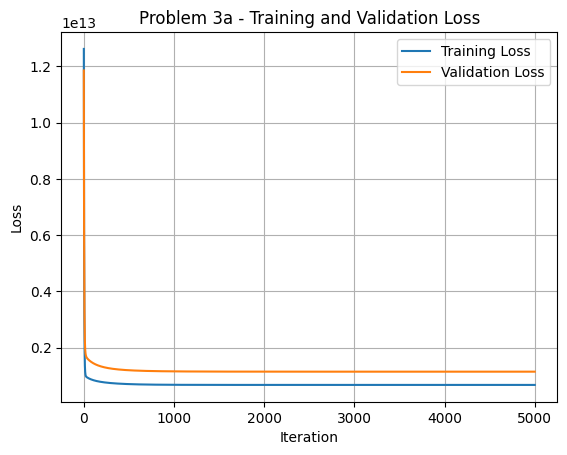

In [121]:
plt.plot(train_3a, label='Training Loss')
plt.plot(val_3a, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Problem 3a - Training and Validation Loss')
plt.legend()
plt.grid()

plt.show()

In [122]:
if best_scaling_3a == "Normalization":
    baseline_train_3a = train_2a_norm[-1]
    baseline_val_3a = val_2a_norm[-1]
else:
    baseline_train_3a = train_2a_std[-1]
    baseline_val_3a = val_2a_std[-1]

print("Problem 2a vs Problem 3a")

print("\nProblem 2a")
print("Training Loss:", baseline_train_3a)
print("Validation Loss:", baseline_val_3a)

print("\nProblem 3a with Parameter Penalty")
print("Training Loss:", train_3a[-1])
print("Validation Loss:", val_3a[-1])

Problem 2a vs Problem 3a

Problem 2a
Training Loss: 675004141072.9407
Validation Loss: 1146340457070.4438

Problem 3a with Parameter Penalty
Training Loss: 675424146416.2015
Validation Loss: 1146487924409.75


Problem 3b

In [123]:
print("Problem 2b normalization variables:")
print([name for name in globals() if "2b" in name.lower()])

Problem 2b normalization variables:
['normalizer_2b', 'X_train_2b_norm', 'X_test_2b_norm', 'results_2b_norm', 'standardizer_2b', 'X_train_2b_std', 'X_test_2b_std', 'results_2b_std', 'best_lr_2b_norm', 'theta_2b_norm', 'train_2b_norm', 'val_2b_norm', 'best_lr_2b_std', 'theta_2b_std', 'train_2b_std', 'val_2b_std', 'training_losses_2b', 'best_training_2b']


In [124]:
# Find the best learning rate for normalization
best_lr_2b_norm = min(
    results_2b_norm,
    key=lambda lr: results_2b_norm[lr][2][-1]
)

theta_2b_norm, train_2b_norm, val_2b_norm = results_2b_norm[best_lr_2b_norm]


# Find the best learning rate for standardization
best_lr_2b_std = min(
    results_2b_std,
    key=lambda lr: results_2b_std[lr][2][-1]
)

theta_2b_std, train_2b_std, val_2b_std = results_2b_std[best_lr_2b_std]


print("Problem 2b Results")

print("\nNormalization")
print("Best Learning Rate:", best_lr_2b_norm)
print("Training Loss:", train_2b_norm[-1])
print("Validation Loss:", val_2b_norm[-1])

print("\nStandardization")
print("Best Learning Rate:", best_lr_2b_std)
print("Training Loss:", train_2b_std[-1])
print("Validation Loss:", val_2b_std[-1])

Problem 2b Results

Normalization
Best Learning Rate: 0.05
Training Loss: 496293120412.3996
Validation Loss: 898741482750.3403

Standardization
Best Learning Rate: 0.01
Training Loss: 496240500004.89264
Validation Loss: 900396859834.4525


In [125]:
if val_2b_norm[-1] < val_2b_std[-1]:
    X_train_3b = X_train_2b_norm
    X_test_3b = X_test_2b_norm
    best_scaling_3b = "Normalization"
    learning_rate_3b = best_lr_2b_norm
else:
    X_train_3b = X_train_2b_std
    X_test_3b = X_test_2b_std
    best_scaling_3b = "Standardization"
    learning_rate_3b = best_lr_2b_std

print("Best scaling for Problem 3b:", best_scaling_3b)
print("Learning rate for Problem 3b:", learning_rate_3b)

Best scaling for Problem 3b: Normalization
Learning rate for Problem 3b: 0.05


In [126]:
iterations_3b = 5000

results_3b = {}

for lam in lambda_values:

    theta_temp, train_temp, val_temp = gradient_descent_regularized(
        X_train_3b,
        y_train,
        X_test_3b,
        y_test,
        learning_rate=learning_rate_3b,
        iterations=iterations_3b,
        lambda_value=lam
    )

    results_3b[lam] = (
        theta_temp,
        train_temp,
        val_temp
    )

    print("Lambda:", lam)
    print("Final Training Loss:", train_temp[-1])
    print("Final Validation Loss:", val_temp[-1])
    print()

Lambda: 0.01
Final Training Loss: 496606088714.237
Final Validation Loss: 898755467776.3109

Lambda: 0.1
Final Training Loss: 499400112847.9754
Final Validation Loss: 898908955835.6561

Lambda: 1.0
Final Training Loss: 525319724726.576
Final Validation Loss: 902755431237.2783

Lambda: 10.0
Final Training Loss: 685466993032.2739
Final Validation Loss: 1007942469926.9484



In [127]:
best_lambda_3b = min(
    results_3b,
    key=lambda lam: results_3b[lam][2][-1]
)

theta_3b, train_3b, val_3b = results_3b[best_lambda_3b]

print("Problem 3b Final Results")
print("Scaling:", best_scaling_3b)
print("Best Lambda:", best_lambda_3b)
print("Learning Rate:", learning_rate_3b)
print("Iterations:", iterations_3b)
print("Theta:", theta_3b)
print("Final Training Loss:", train_3b[-1])
print("Final Validation Loss:", val_3b[-1])

Problem 3b Final Results
Scaling: Normalization
Best Lambda: 0.01
Learning Rate: 0.05
Iterations: 5000
Theta: [1914511.78300134 3419186.62617666  462727.9435163  3291979.62129734
 1268396.45577309  420649.15689088  246971.8164557   431574.25532833
  713386.92511548  810651.69672364  747835.20349442  636496.14208782]
Final Training Loss: 496606088714.237
Final Validation Loss: 898755467776.3109


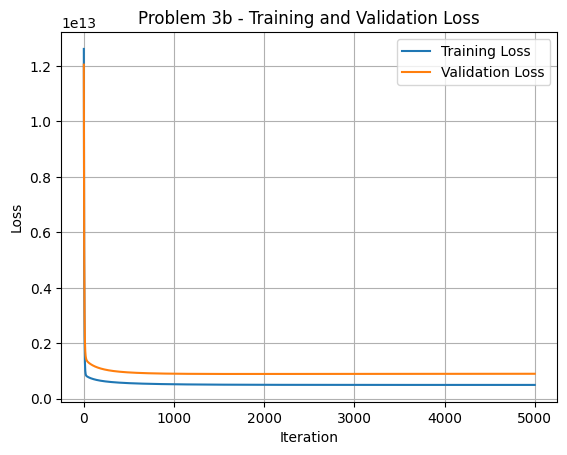

In [128]:
plt.plot(train_3b, label='Training Loss')
plt.plot(val_3b, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Problem 3b - Training and Validation Loss')
plt.legend()
plt.grid()

plt.show()

In [129]:
if best_scaling_3b == "Normalization":
    baseline_train_3b = train_2b_norm[-1]
    baseline_val_3b = val_2b_norm[-1]
else:
    baseline_train_3b = train_2b_std[-1]
    baseline_val_3b = val_2b_std[-1]

print("Problem 2b vs Problem 3b")

print("\nProblem 2b")
print("Training Loss:", baseline_train_3b)
print("Validation Loss:", baseline_val_3b)

print("\nProblem 3b with Parameter Penalty")
print("Training Loss:", train_3b[-1])
print("Validation Loss:", val_3b[-1])

Problem 2b vs Problem 3b

Problem 2b
Training Loss: 496293120412.3996
Validation Loss: 898741482750.3403

Problem 3b with Parameter Penalty
Training Loss: 496606088714.237
Validation Loss: 898755467776.3109


In [132]:
!ls /content

'Housing (1).csv'  'Housing (3).csv'   Noah_Harris_801353171_HW2.ipynb
'Housing (2).csv'   Housing.csv        sample_data


In [133]:
!jupyter nbconvert --to html --embed-images "/content/Noah_Harris_801353171_HW2.ipynb"

[NbConvertApp] Converting notebook /content/Noah_Harris_801353171_HW2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 692902 bytes to /content/Noah_Harris_801353171_HW2.html
